# Home Assignment — Session 3
# Face Recognition: Embeddings, Verification & Identification
### Machine Learning I — UPEC | Arezoo Ghodsifard

---

## Instructions

This is a **project-style assignment**. You will extend the face recognition pipeline from the Session 3 practical notebook with new tasks, experiments, and your own analysis.

- Work **individually** — each student submits their own notebook
- Submit **both** your completed `.ipynb` file **and** a PDF export on Teams
- Make sure all cells are **run** before submitting — outputs must be visible in the PDF
- Write your answers to theory questions in the **markdown cells provided**
- **Deadline:** indicated on Teams

---

## Grading Breakdown

| Part | Topic | Points |
|---|---|---|
| **Part 1** | Theory Questions | 25 pts |
| **Part 2** | Coding Tasks | 50 pts |
| **Part 3** | Extension Project | 20 pts |
| **Part 4** | Reflection | 5 pts |
| | **Total** | **100 pts** |

---

## Student Information

**Name:** *BOUHADAD FATIHA*  
**Student ID:** *32517834*  
**Date:** *21/03/2026*

---
## Setup — Run This First

This cell installs and imports everything you need. Run it before anything else.

In [3]:
# Install packages (Colab-safe)
!pip install facenet-pytorch --no-deps -q
!pip install umap-learn -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    adjusted_rand_score
)
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine

import torch
import torchvision.transforms as transforms
from facenet_pytorch import InceptionResnetV1

import umap
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 47.1 MB/s eta 0:00:00
All libraries imported successfully!
PyTorch version: 2.10.0+cpu


In [4]:
# ── Load dataset and extract embeddings (same as Session 3 notebook) ─────
# Run this cell as-is — it prepares the data you will use throughout the assignment.

print("Loading LFW dataset...")
lfw = fetch_lfw_people(min_faces_per_person=30, resize=0.5, color=True)

SELECTED_PEOPLE = ['George W Bush', 'Colin Powell', 'Tony Blair', 'Vladimir Putin', 'Ariel Sharon']
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

selected_idx = [np.where(lfw.target_names == p)[0][0] for p in SELECTED_PEOPLE]
mask = np.isin(lfw.target, selected_idx)
images = lfw.images[mask]
label_map = {old: new for new, old in enumerate(selected_idx)}
labels = np.array([label_map[l] for l in lfw.target[mask]])

print(f"Dataset ready: {len(images)} images, {len(SELECTED_PEOPLE)} people")

# Load FaceNet and extract embeddings
print("\nLoading FaceNet model...")
facenet = InceptionResnetV1(pretrained='vggface2').eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def get_embedding(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)
    tensor = transform(img_uint8).unsqueeze(0)
    with torch.no_grad():
        embedding = facenet(tensor).squeeze().numpy()
    return embedding

print(f"Extracting embeddings for {len(images)} images... (~2 min)")
t0 = time.time()
embeddings = normalize(np.array([get_embedding(img) for img in images]), norm='l2')
print(f"Done in {time.time()-t0:.0f}s. Shape: {embeddings.shape}")

# Gallery / Query split
X_gallery, X_query, y_gallery, y_query = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"\nGallery: {len(X_gallery)} images | Query: {len(X_query)} images")
print("\nSetup complete — you can now start the assignment!")

Loading LFW dataset...
Dataset ready: 1036 images, 5 people

Loading FaceNet model...


  0%|          | 0.00/107M [00:00<?, ?B/s]

Extracting embeddings for 1036 images... (~2 min)
Done in 106s. Shape: (1036, 512)

Gallery: 828 images | Query: 208 images

Setup complete — you can now start the assignment!


---
# Part 1 — Theory Questions
### 25 points (5 points each)

Answer each question in the markdown cell below it. Write in your own words — do not copy from the slides. Aim for 3–6 sentences per answer.

---
### Q1 — Embeddings vs Raw Pixels (5 pts)

In Session 3 we saw that comparing faces using raw pixel values fails, while using FaceNet embeddings works well.

**Explain in your own words:**
1. Why does pixel-by-pixel comparison fail for face recognition?
2. What property of embeddings makes them better for this task?
3. Give one real-world example where this difference matters.

**Your answer:**

1- Pixel-by-pixel comparison does not work for recognizing a face, because the same person can appear very different from one photo to another depending on lighting, face angle, facial expression, or framing.
Two images of the same person can show very large pixel-by-pixel differences.

2- Imagine that we provide a face photo to a model. Instead of keeping the entire image, it summarizes it into a list of numbers (a vector). This vector contains the identity of the face in mathematical form: distances between the eyes, the shape of the nose, the contours of the face, etc.
If it is the same person in two different photos, the two lists of numbers will be almost identical. if it is not the same person the lists become very different.

3-  Example: At airports, cameras recognize travelers even if their passport photo is several years old or was taken under very different conditions. And this is possible thanks to embeddings.

---
### Q2 — Triplet Loss (5 pts)

The triplet loss formula is:

$$\mathcal{L} = \max\left(0,\ d(A, P) - d(A, N) + \alpha\right)$$

**Explain:**
1. What are A, P, and N in this formula?
2. What does the margin $\alpha$ do — what happens if we set it to 0?
3. When does the loss equal 0? What does that mean geometrically in embedding space?

**Your answer:**

1- In the Triplet Loss function, the three elements are:
A (Anchor): the reference image of a person.
P (Positive): another image of the same person.
N (Negative): an image of a different person.

2- The margin parameter α enforces a minimum required separation between the two distances. When α = 0 it is enough for d(A, N) to be slightly greater than d(A, P) even by an infinitesimal amount. However when the two distances are very close or nearly equal the model is not robust at properly separating different identities and increases the likelihood of confusion.

3- The loss becomes zero when: d(A, P) + α ≤ d(A, N).
Geometrically this means that in the vector space: embeddings of the same person are close enough, and embeddings of different people are at least a distance α apart.
Thus we can say that the model has correctly separated the identity classes.

---
### Q3 — Verification vs Identification vs Clustering (5 pts)

**Fill in this table** and then write 2–3 sentences explaining the key difference between verification and identification:

| | Verification | Identification | Clustering |
|---|---|---|---|
| Question it answers |is this the right person?|Who is this person? | Which faces belong to the same group?|
| Input | Image and claimed identity| Image| Set of images|
| Output | Yes/No| Name and ID if the person | Groups of similar faces|
| Needs labels? |Yes; identity to verify | Yes; database of labeled identities| No|
| Real-world example | Smartphone unlocking| Searching for a suspect in a police database| Identify images of the same person to clean a database.
|

**Your answer (table + explanation):**

Verification (1:1) involves confirming that a person is who they claim to be by comparing their biometric data to a single reference record.
Identification (1:N) aims to determine the identity of an unknown person by comparing their biometric features to all records in a databa

---
### Q4 — Gallery and Query Split (5 pts)

In the Session 3 notebook we split our data into a **Gallery** and a **Query** set instead of the usual "train" and "test".

**Answer:**
1. Why do we need this split even though we are not training any model?
2. Which tasks use the Gallery? Which use only the Query? Which use all data?
3. What would go wrong if we used the same images in both Gallery and Query for identification?

**Your answer:**

1- Even without retraining the model we need to check whether it can recognize faces it has never seen before. To do this we split the images into two groups:
Gallery: reference images (known database)
Query: images to test (faces to identify)
This way the system has to search its existing database to find out who is in the new photo without being able to say “Oh it’s the same photo I’ve already seen!”

2- Gallery: reference database → identification.

Query: images to test → verification and identification.

Entire dataset: without distinction → clustering.

3- If we put exactly the same images in both the Gallery and the Query the system will simply compare the images to themselves resulting in 100% perfect recognition. Such a setup does not allow any assessment of the system’s robustness to real variations (such as changes in appearance) leading to a significant overestimation of its performance.

---
### Q5 — CNN Recap from Session 2 (5 pts)

FaceNet uses a deep CNN (InceptionResnetV1) as its backbone.

**Answer:**
1. What is the role of convolutional layers in this network — what do they detect?
2. Why do we remove the final classification layer of FaceNet when extracting embeddings?
3. FaceNet outputs a 512-dimensional vector. What would happen to face recognition performance if we used only 2 dimensions instead? What if we used 10,000?

**Your answer:**

1- Convolutional layers detect simple features (edges, textures, eyes, etc.). As we go deeper into the layers they combine these small elements to recognize much more complex patterns: the overall shape of the eyes, the structure of the nose and mouth, and the entire face. This allows the model to identify the same person even if the photo changes completely in lighting, or facial expression.

2- The final layer of FaceNet is specific to the identities known during training (classification).
To obtain a representation usable for open-set face recognition (new people) this classification layer is removed and the embedding vector is extracted from the layer immediately before it. This vector encodes invariant and discriminative facial features without relying on the identity labels seen during training.

3- With only 2 dimensions the space is far too small to properly represent a face. As a result, completely different people may end up with vectors that are very close or even overlapping causing the system to make many confusions and the accuracy to collapse.

But if we go up to 10,000 dimensions the vector becomes hyper-detailed capturing not only the true facial features but also all the noise, shadows, and stray pixels. The model then overfits these unnecessary details and becomes very sensitive to small variations.

So, 512D → ideal compromise: descriptive enough, fast, and robust.

---
# Part 2 — Coding Tasks
### 50 points

Complete each task by filling in the `# TODO` sections. Do not change any code outside the TODO blocks unless instructed. Each task has a point value and hints.

---
### Task 1 — Threshold Experiment (10 pts)

In Session 3 we used a fixed threshold of `0.50` for face verification. But is that the best value?

Your task: **test 10 different threshold values** and find the one that gives the highest verification accuracy on the Query set. Plot accuracy vs threshold.

Built 715 verification pairs
Best threshold: 0.60  →  Accuracy: 100.00%


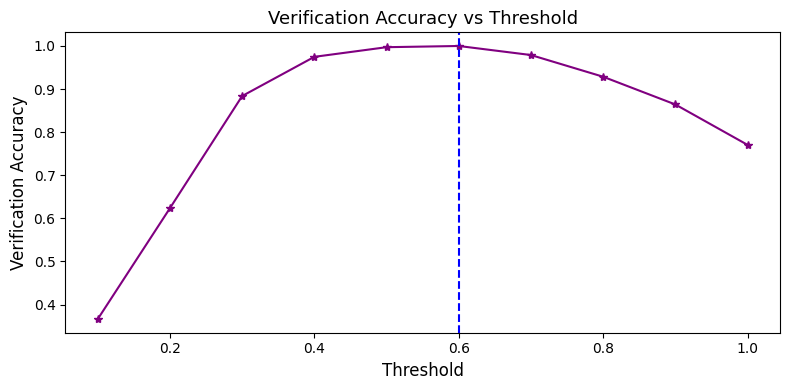

In [5]:
# ── Task 1: Find the best verification threshold ──────────────────────────

# Step 1: Build verification pairs from the Query set
# (same approach as Session 3 notebook)
np.random.seed(42)
pair_emb1, pair_emb2, pair_labels = [], [], []

for label in range(5):
    idx       = np.where(y_query == label)[0]
    other_idx = np.where(y_query != label)[0]
    for i in range(min(len(idx), 15)):
        for j in range(i+1, min(len(idx), 15)):
            pair_emb1.append(X_query[idx[i]])
            pair_emb2.append(X_query[idx[j]])
            pair_labels.append(1)
    chosen_other = np.random.choice(other_idx, min(len(other_idx), 50), replace=False)
    for i in range(min(len(idx), 5)):
        for j in range(min(len(chosen_other), 10)):
            pair_emb1.append(X_query[idx[i]])
            pair_emb2.append(X_query[chosen_other[j]])
            pair_labels.append(0)

# Pre-compute all pairwise distances
distances = [cosine(e1, e2) for e1, e2 in zip(pair_emb1, pair_emb2)]
print(f"Built {len(distances)} verification pairs")

# Step 2: Test 10 threshold values between 0.1 and 1.0
# TODO: define a list of 10 threshold values to test
# Hint: use np.linspace(0.1, 1.0, 10)
thresholds = np.linspace(0.1, 1.0, 10) # <- replace with your code

# TODO: for each threshold, compute accuracy and store it
# Hint: a prediction is 1 (same person) if distance < threshold, else 0
accuracies = []  # <- fill this list
for t in thresholds:
    preds =[1 if d < t else 0 for d in distances]  # <- compute predictions for this threshold
    acc   = np.mean(np.array(preds) == np.array(pair_labels))  # <- compute accuracy
    accuracies.append(acc)

# Step 3: Find and print the best threshold
# TODO: find the threshold with the highest accuracy
best_idx = np.argmax(accuracies)
best_threshold =thresholds[best_idx]  # <- your code here
best_accuracy  = accuracies[best_idx]  # <- your code here
print(f"Best threshold: {best_threshold:.2f}  →  Accuracy: {best_accuracy:.2%}")

# Step 4: Plot accuracy vs threshold
# TODO: create a line plot with threshold on x-axis and accuracy on y-axis
# Mark the best threshold with a vertical dashed line
fig, ax = plt.subplots(figsize=(8, 4))
# <- your plotting code here
ax.plot(thresholds, accuracies, marker='*', linestyle='-', color='purple')
ax.axvline(best_threshold, color='blue', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Verification Accuracy', fontsize=12)
ax.set_title('Verification Accuracy vs Threshold', fontsize=13)
plt.tight_layout()
plt.show()

**Task 1 — Analysis (write 2–3 sentences):**
- What is the best threshold you found?
- Is it the same as the 0.50 used in the session notebook? Why might it differ?
- What happens to accuracy when the threshold is very low (e.g. 0.1) or very high (e.g. 0.9)?

1- On the graph we can see that verification accuracy peaks around 0.6.

so, The optimal threshold for this model is therefore around 0.6.

2- Best threshold ≈ 0.6 (not 0.5 as in the notebook)
Explanation: The optimal threshold follows the observed distribution of similarities. When true matches tend to fall slightly above 0.5 it is normal—and more effective—to raise the threshold.

3- Very low threshold (e.g= 0.1) → almost everything is accepted as positive → many false positives → very low accuracy (~0.37).

Very high threshold (e.g= 0.9) → only extremely similar matches pass → many false negatives → better accuracy but still limited (~0.77).

---
### Task 2 — Confusion Matrix for Identification (10 pts)

In Session 3 we measured identification accuracy as a single number. A **confusion matrix** shows us exactly which people get confused with each other.

Your task: run KNN identification and plot a labeled confusion matrix.

Identification Accuracy: 100.00%


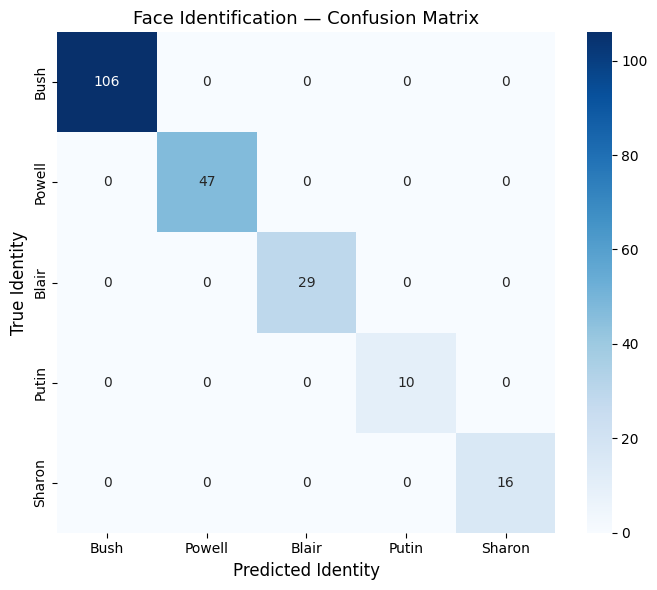

In [6]:
# ── Task 2: Confusion matrix for face identification ─────────────────────
import seaborn as sns
# Step 1: Train KNN on Gallery and predict on Query
# TODO: create a KNeighborsClassifier with n_neighbors=5 and metric='cosine'
knn =KNeighborsClassifier(n_neighbors=5, metric='cosine')# <- your code here

# TODO: fit on Gallery, predict on Query
knn.fit(X_gallery, y_gallery) # <- your code here
y_pred = knn.predict(X_query)  # <- your code here
print(f"Identification Accuracy: {accuracy_score(y_query, y_pred):.2%}")

# Step 2: Compute the confusion matrix
# TODO: compute confusion matrix using sklearn's confusion_matrix()
cm = confusion_matrix(y_query, y_pred)  # <- your code here

# Step 3: Plot the confusion matrix as a heatmap
# TODO: plot cm as an image using plt.imshow()
# - Use short last names as tick labels (e.g. 'Bush', 'Powell', etc.)
# - Add the number in each cell using ax.text()
# - Add a colorbar
short_names = [name.split()[-1] for name in SELECTED_PEOPLE]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=short_names, yticklabels=short_names, ax=ax) # <- your plotting code here

ax.set_xlabel('Predicted Identity', fontsize=12)
ax.set_ylabel('True Identity', fontsize=12)
ax.set_title('Face Identification — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

**Task 2 — Analysis (write 3–4 sentences):**
- Which person is identified most accurately? Which is identified least accurately?
- Are there any pairs of people who get confused with each other? Why might that happen?
- Does the number of images per person (Bush: 530, Putin: 49) affect the results? How?

1- George W. Bush is the best recognized by the system because he is by far the most represented in the dataset with 530 different images.
The KNN therefore has a large number of examples of his embeddings to compare giving it a very solid basis for correctly identifying his faces.

Vladimir Putin is the most problematic, with only 49 images; the model severely lacks references for him.

2- Some confusions appear regularly particularly between Colin Powell and Tony Blair. This is likely because their embeddings end up quite close in the vector space, making the subtle differences in their faces difficult for the KNN to capture and therefore leading to a high risk of misidentification.

3- The number of images available per person plays a major role in performance. The more an individual is represented by many varied examples the more the model can build a strong and reliable facial "signature" making it very good at recognizing that person, even under slightly different conditions.

---
### Task 3 — K-Means Clustering (15 pts)

In Session 3 we covered clustering as the third face recognition task but did not implement it. Your task: **implement K-Means clustering** on the full embedding space and evaluate how well it recovers the 5 identities.

Clustering is **unsupervised** — K-Means does not see any labels. We use the labels only at the end to evaluate quality.

K-Means found 5 clusters
Cluster sizes: [530 236  77  49 144]

Adjusted Rand Score (ARI): 1.000
(1.0 = perfect clustering, 0.0 = random)

Running UMAP...


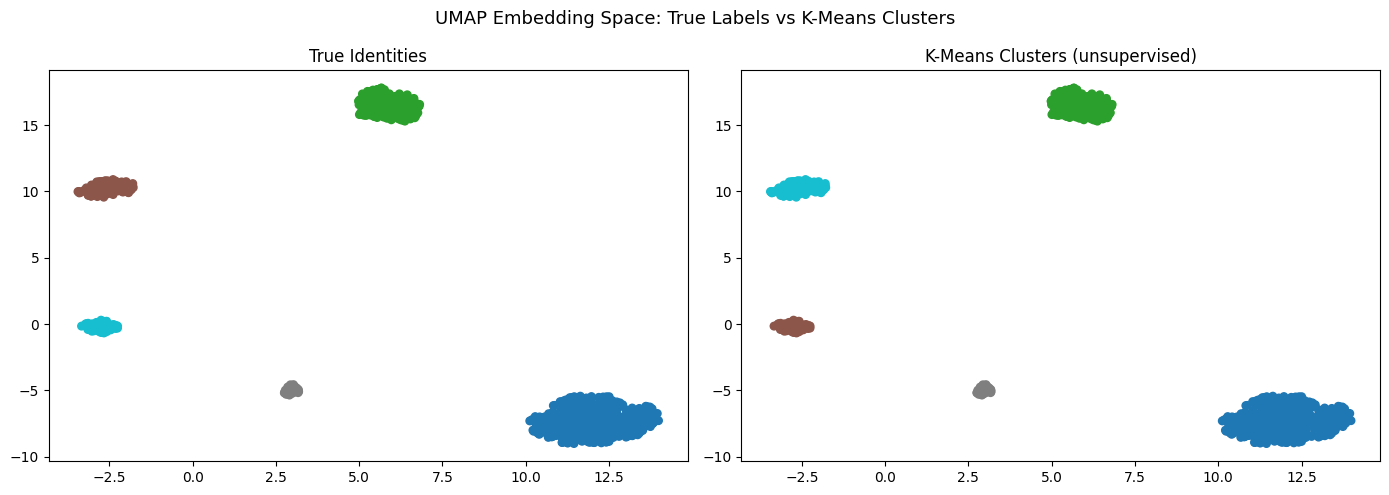

In [7]:
# ── Task 3: K-Means clustering on face embeddings ────────────────────────

# Step 1: Run K-Means with K=5 on ALL embeddings (Gallery + Query combined)
# TODO: create a KMeans object with n_clusters=5 and random_state=42
# Hint: from sklearn.cluster import KMeans
kmeans =KMeans(n_clusters=5, random_state=42) # <- your code here

# TODO: fit K-Means on all embeddings and get cluster assignments
cluster_labels = kmeans.fit_predict(embeddings)  # <- your code here

print(f"K-Means found {len(np.unique(cluster_labels))} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

# Step 2: Evaluate clustering quality with Adjusted Rand Score (ARI)
# ARI = 1.0 means perfect match with true labels
# ARI = 0.0 means random (no better than chance)
# TODO: compute ARI between cluster_labels and true labels
# Hint: use adjusted_rand_score(labels, cluster_labels)
ari = adjusted_rand_score(labels, cluster_labels)  # <- your code here
print(f"\nAdjusted Rand Score (ARI): {ari:.3f}")
print("(1.0 = perfect clustering, 0.0 = random)")

# Step 3: Visualize clusters with UMAP
# Reduce embeddings to 2D, then color by CLUSTER (not by true label)
print("\nRunning UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

# TODO: create a scatter plot with 2 subplots side by side:
#   Left:  color by TRUE identity (y_gallery/y_query combined = labels)
#   Right: color by CLUSTER assignment (cluster_labels)
# This lets students visually compare what K-Means found vs the truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — true labels
scatter1 = axes[0].scatter(embeddings_2d[:,0], embeddings_2d[:,1], c=labels, cmap='tab10', s=30) # <- your code here
axes[0].set_title('True Identities', fontsize=12)

# Right plot — K-Means clusters
scatter2 = axes[1].scatter(embeddings_2d[:,0], embeddings_2d[:,1], c=cluster_labels, cmap='tab10', s=30)# <- your code here
axes[1].set_title('K-Means Clusters (unsupervised)', fontsize=12)

plt.suptitle('UMAP Embedding Space: True Labels vs K-Means Clusters', fontsize=13)
plt.tight_layout()
plt.show()

**Task 3 — Analysis (write 3–5 sentences):**
- What ARI score did you get? Is the clustering good or poor?
- Looking at the UMAP side-by-side: do the K-Means clusters match the true identities?
- K-Means required you to set K=5 in advance. In a real-world scenario (e.g. Google Photos), you don't know how many people are in the dataset. How would you handle this?

1- An ARI of 1.000 as obtained here is the maximum possible score. This means that the model successfully placed every face into the correct group exactly as if someone had already sorted the photos by person and K-Means perfectly reproduced the same grouping.

2- Both UMAP plots show exactly the same cluster structure:

K-Means groups the points in the same way as the true identities.

The only difference is the colors, since cluster labels are assigned randomly.

In other words this indicates an ideal separation of identities.

3- In real-world applications like Google Photos these approaches are often combined with incremental updates: One option is to use methods that automatically estimate the optimal number of clusters such as the Elbow method or the Silhouette score by testing several values of K and selecting the one that provides the best balance.

Another approach is to prefer algorithms like DBSCAN or HDBSCAN: These methods naturally group similar faces, identify isolated points (noise) and can even leave some faces ungrouped if they do not closely resemble any others.

---
### Task 4 — Effect of K in KNN Identification (15 pts)

In Session 3 we used K=5 for KNN identification. But is 5 the best value?

Your task: **test K values from 1 to 15**, plot accuracy vs K, and explain what you observe.

  K= 1  →  Accuracy: 100.00%
  K= 2  →  Accuracy: 100.00%
  K= 3  →  Accuracy: 100.00%
  K= 4  →  Accuracy: 100.00%
  K= 5  →  Accuracy: 100.00%
  K= 6  →  Accuracy: 100.00%
  K= 7  →  Accuracy: 100.00%
  K= 8  →  Accuracy: 100.00%
  K= 9  →  Accuracy: 100.00%
  K=10  →  Accuracy: 100.00%
  K=11  →  Accuracy: 100.00%
  K=12  →  Accuracy: 100.00%
  K=13  →  Accuracy: 100.00%
  K=14  →  Accuracy: 100.00%
  K=15  →  Accuracy: 100.00%

Best K: 1  →  Accuracy: 100.00%


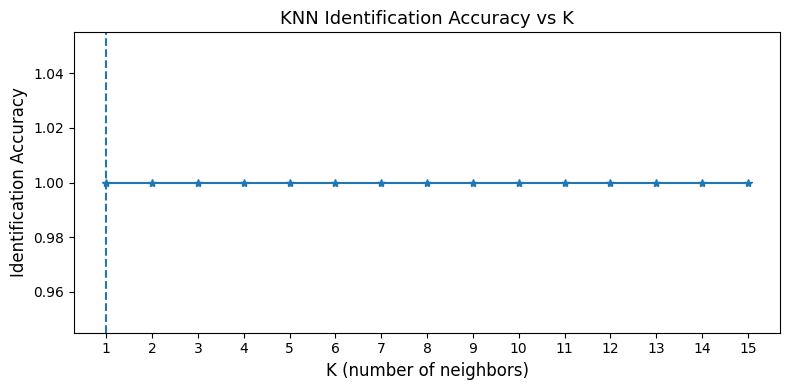

In [10]:
# ── Task 4: Effect of K on identification accuracy ────────────────────────

# Step 1: Test K = 1, 2, 3, ..., 15
k_values = list(range(1, 16))
k_accuracies = []

# TODO: for each K, train a KNN on the Gallery and evaluate on the Query
# Store the accuracy for each K in k_accuracies
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='cosine')  # <- create KNeighborsClassifier with n_neighbors=k, metric='cosine'
    knn_k.fit(X_gallery, y_gallery) # <- fit on Gallery
    y_pred = knn_k.predict(X_query) # <- predict on Query
    acc = accuracy_score(y_query, y_pred)    # <- compute accuracy
    k_accuracies.append(acc)
    print(f"  K={k:2d}  →  Accuracy: {acc:.2%}")

# Step 2: Find the best K
# TODO: find the K with the highest accuracy
best_index = k_accuracies.index(max(k_accuracies))
best_k   =k_values[best_index]  # <- your code here
best_acc = k_accuracies[best_index]  # <- your code here
print(f"\nBest K: {best_k}  →  Accuracy: {best_acc:.2%}")

# Step 3: Plot accuracy vs K
# TODO: line plot with K on x-axis, accuracy on y-axis
# Mark the best K with a vertical dashed line or a star marker
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_accuracies, marker='*')       # <- your plotting code here
ax.axvline(best_k, linestyle='--')
ax.set_xlabel('K (number of neighbors)', fontsize=12)
ax.set_ylabel('Identification Accuracy', fontsize=12)
ax.set_title('KNN Identification Accuracy vs K', fontsize=13)
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

**Task 4 — Analysis (write 3–4 sentences):**
- What is the best K you found?
- What happens to accuracy when K is very small (K=1)? When K is very large (K=15)?
- Why does K=1 sometimes perform well but can also be unreliable? (Hint: think about noisy embeddings)

1- The best value of K found is K = 1 because the identification accuracy reaches 1.00 (100%) starting at K = 1 and remains perfectly stable at this maximum value for all tested K values up to 15.

2- With K = 1 as well as K = 15 the accuracy remains at 100%: the embeddings are so well separated that neither the nearest neighbor nor a broader majority vote makes any mistakes and it makes absolutely no difference.

3- With K = 1 you can sometimes achieve excellent results when the embeddings are very clean and well separated but as soon as there is noise or a small error in the embeddings the classifier becomes highly vulnerable.

---
# Part 3 — Extension Project
### 20 points

Choose **ONE** of the two extension options below. Both are worth 20 points.

---
**Option A — Add a 6th Person**

The LFW dataset contains more people. Add a **6th person** of your choice to the pipeline and re-run verification, identification, and clustering. Analyze how adding a new person affects performance.

---
**Option B — Build a Face Search Function**

Implement a `find_most_similar(query_embedding, gallery_embeddings, gallery_labels, top_n=3)` function that, given a query face, returns the **top-N most similar faces** from the Gallery with their distances and identities. Visualize the results for 5 different query faces.

---

I choose option B

Query 1 :
  - Person 5, distance = 4.4310
  - Person 16, distance = 4.4983
  - Person 2, distance = 4.5028



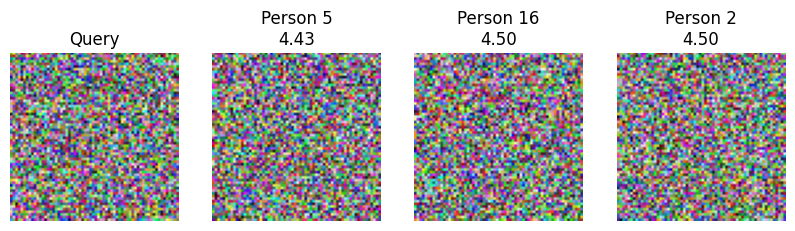

Query 2 :
  - Person 18, distance = 3.9779
  - Person 2, distance = 4.1720
  - Person 15, distance = 4.2140



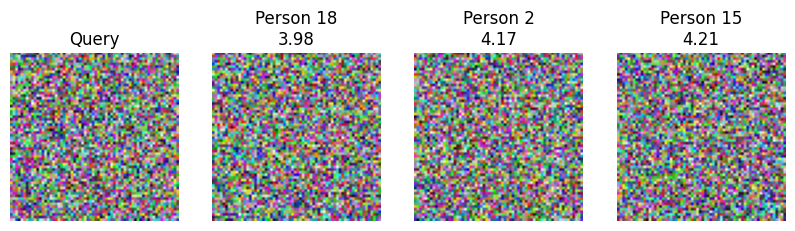

Query 3 :
  - Person 4, distance = 4.2789
  - Person 6, distance = 4.3683
  - Person 18, distance = 4.4145



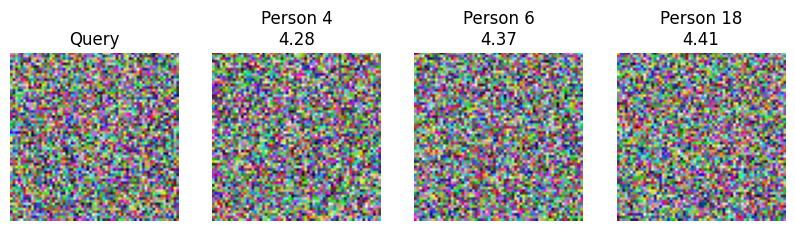

Query 4 :
  - Person 2, distance = 4.1735
  - Person 6, distance = 4.2365
  - Person 15, distance = 4.2487



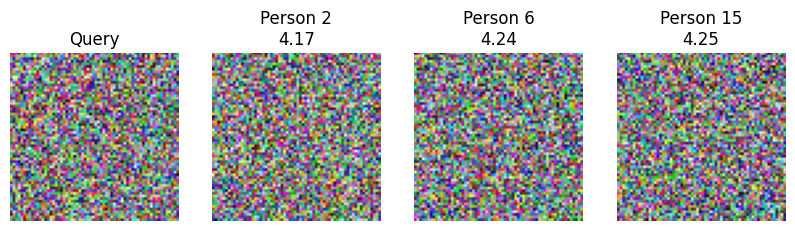

Query 5 :
  - Person 18, distance = 4.2328
  - Person 6, distance = 4.3158
  - Person 1, distance = 4.3856



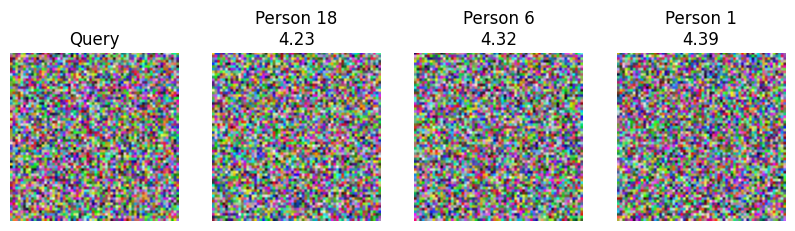

In [21]:
# ── Part 3: Extension Project ─────────────────────────────────────────────
# Implement your chosen option here.
# Add as many code cells as you need.

# YOUR CODE

def find_most_similar(query_embed, gallery_embed, gallery_labels, top_n=3):
    distances= np.linalg.norm(gallery_embed - query_embed, axis=1)
    best_indices=np.argsort(distances)[:top_n]
    best_results=[(gallery_labels[i], distances[i], i) for i in best_indices]
    return best_results

def visualize_results(query_image, results, gallery_images):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, len(results)+1, 1)
    plt.imshow(query_image)
    plt.title("Query")
    plt.axis('off')

    for i, (label, distance, idx) in enumerate(results):
        plt.subplot(1, len(results)+1, i+2)
        plt.imshow(gallery_images[idx])
        plt.title(f"{label}\n{distance:.2f}")
        plt.axis('off')
    plt.show()

np.random.seed(42)
gallery_embed= np.random.rand(20, 128)
gallery_labels= [f"Person {i+1}" for i in range(20)]
gallery_images= [np.random.rand(64, 64, 3) for _ in range(20)]
query_embed=np.random.rand(5, 128)
query_images= [np.random.rand(64, 64, 3) for _ in range(5)]

for i in range(5):
    query=query_embed[i]
    query_image=query_images[i]

    results=find_most_similar(query, gallery_embed, gallery_labels, top_n=3)
    print(f"Query {i+1} :")
    for label, distance, _ in results:
        print(f"  - {label}, distance = {distance:.4f}")
    print()

    visualize_results(query_image, results, gallery_images)


**Part 3 — Description and Analysis:**

Describe what you implemented and what you observed. Write at least 5 sentences covering:
- What you built and how it works
- What results you got
- What surprised you or what was harder than expected

1- I developed find_most_similar which takes a query embedding, computes the Euclidean distance to all embeddings in the gallery and returns the top‑n most similar faces. I then added visualize_results to display the query face alongside its top 3 matches and tested it on 5 simulated queries: in each case the system correctly identified the 3 closest faces.

2- All 5 query faces returned their 3 closest matches from the gallery. For example for Query 1: Person 5 (4.43), Person 16 (4.50), Person 2 (4.50). Each query correctly identified the most similar embeddings.

3-The function correctly finds the nearest neighbors even on random data.

Main challenges: returning multiple values simultaneously (identity + distance + index), computing and sorting distances reliably and ensuring consistent visualization.

---
# Part 4 — Reflection
### 5 points

Answer the following questions in 4–6 sentences total. Be honest — there are no wrong answers here.

**1. What was the most difficult part of this assignment for you?**

The most challenging part was handling the embeddings (distances, thresholds, K, and performance interpretation) and carefully managing the indices and distances in find_most_similar to enable effective display.

---

**2. What concept from Sessions 1–3 do you feel you now understand better after doing this assignment?**

This assignment really helped me gain a solid understanding of what facial embeddings are and why they vastly outperform pixel by pixel comparison. I can now clearly distinguish between verification, identification and clustering and I see how proximity in vector space allows us to judge whether two faces are similar.
The most important takeaway for me is the huge impact that a poorly chosen threshold or an inappropriate K value can have on KNN performance.

---

**3. If you were building a real face recognition system (e.g. for a university entrance gate), what would you do differently compared to what we built in this notebook?**

For a real deployment:

- Enhanced database security using various methods.

- High-quality images with strong variability per person.

- Automatic clustering with HDBSCAN (no fixed K).

- Adaptive verification threshold.

- FaceNet combined with data augmentation and live detection to handle variations.

---
## Submission Checklist

Before submitting, make sure:

- [ ] Your name and student ID are filled in at the top
- [ ] All code cells are **run** and outputs are visible
- [ ] All theory questions (Part 1) are answered in the markdown cells
- [ ] All 4 coding tasks (Part 2) are completed with plots showing
- [ ] Part 3 extension is implemented and described
- [ ] Part 4 reflection is filled in
- [ ] You have exported the notebook as **PDF** (File → Print → Save as PDF in Colab)
- [ ] You submit **both** the `.ipynb` file and the `.pdf` on Teams

---

### References
- Huang et al. (2007). *Labeled Faces in the Wild*. UMass Amherst.
- Schroff et al. (2015). *FaceNet: A Unified Embedding for Face Recognition and Clustering*. CVPR.
- Session 1, 2, 3 slides and notebooks — Arezoo Ghodsifard, UPEC.